In [1]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2
    
import os
import sys

# add parent directory to sys.path to import STL package modules
PARENT_DIR = os.path.dirname(os.path.abspath(os.getcwd() + "/../regrid_to_healpix"))
sys.path.append(PARENT_DIR)

In [8]:
import healpix_geo 
import numpy as np

level=15
ndata=128
cell_ids=3*4**level+np.arange(ndata*ndata)
lon,lat = healpix_geo.nested.healpix_to_lonlat(cell_ids, level,ellipsoid='WGS84')
val=lon

In [29]:
from regrid_to_healpix.regrid_to_healpix_nearest import Set

nr = Set(lon_deg=lon, lat_deg=lat, level=level, device="cuda")  # Npt=1 imposé dans nearest
# puis:
hval     = nr.transform(val)  # selon ton API
rval     = nr.invert(hval).cpu().numpy()[0] 
cell_ids = nr.get_cell_ids()
hval.shape,cell_ids.shape

(torch.Size([1, 16384]), (16384,))

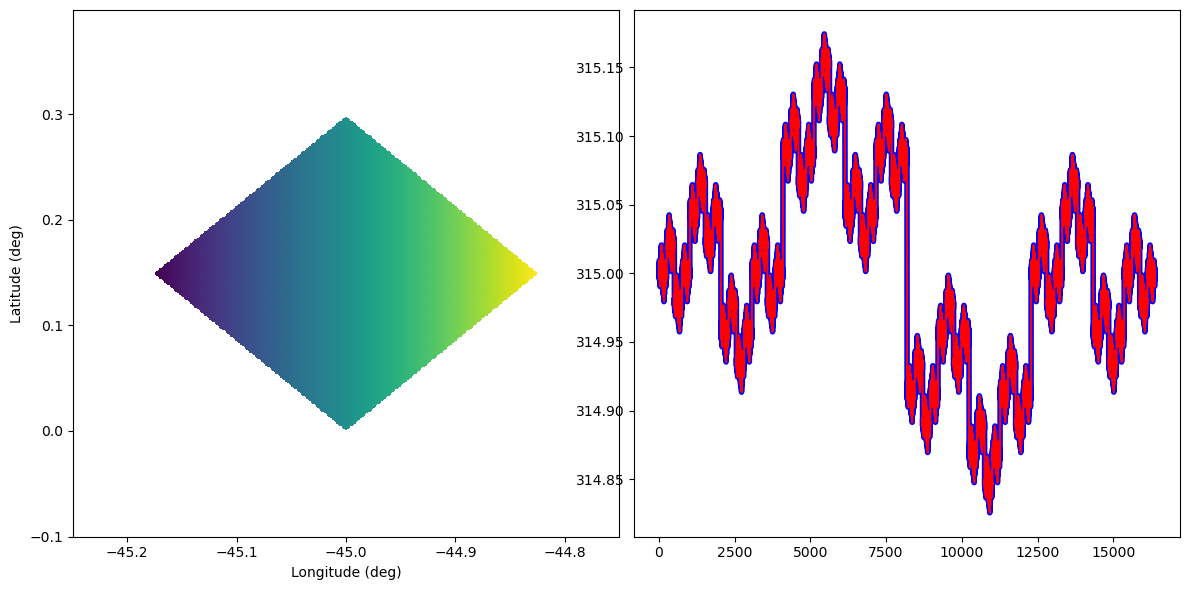

In [37]:
from foscat.Plot import lgnomproject
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
lgnomproject(cell_ids,hval.cpu().numpy()[0],2**level,hold=False,fov_deg=0.5,interp=False,sub=(1,2,1))
plt.subplot(1,2,2)
plt.plot(lon,color='b',lw=4)
plt.plot(rval,color='r')

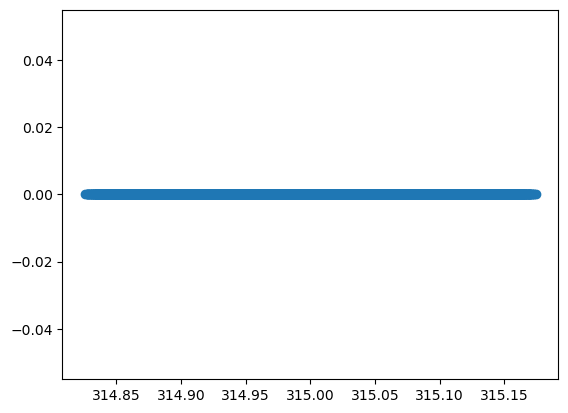

In [34]:
plt.scatter(lon,abs(rval-lon))